**Extraire channels pour l'inference**

In [48]:
image_name = "Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean"

In [ ]:
import rasterio
import numpy as np

# Ouvrir l'image
with rasterio.open(f"./preprocessing/cleaning_data/{image_name}.tif") as src:
    # Lire les 3 bandes 
    red = src.read(6)
    green = src.read(4)
    blue = src.read(2)
    NIR = src.read(10)
    
    profile = src.profile.copy()

# Empiler les bandes 
rgb = np.stack((red, green, blue, NIR), axis=0)

# Modifier le profil
profile.update({
    "count": 4,            
    "dtype": rgb.dtype,    
    "driver": "GTiff"     
})

# Sauvegarder nouveau fichier
output_path = f"./preprocessing/cleaning_data/{image_name}_RGB.tif"
with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(rgb)

**Obtenir l'image qui contient seulement l'endroits qu'on doit segmenter (one polygon)**

In [50]:
image_name = "Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB"

In [51]:
import os
import rasterio
from rasterio.mask import mask
import geopandas as gpd

import rasterio
from rasterio.enums import Resampling

tif_path = f"./preprocessing/cleaning_data/{image_name}.tif"
bbox_shapefile = f"./preprocessing/cleaning_data/example_rectangle_one_polygon.shp"

output_folder = "inference/inputs"
os.makedirs(output_folder, exist_ok=True)

#   Charger les shapefiles
bbox_gdf = gpd.read_file(bbox_shapefile)

with rasterio.open(tif_path) as src:
    if bbox_gdf.crs != src.crs:
        bbox_gdf = bbox_gdf.to_crs(src.crs)

    for i, bbox_geom in enumerate(bbox_gdf.geometry):
        try:
            # Masker l’image avec la bbox
            clipped_image, clipped_transform = mask(src, [bbox_geom], crop=True)
            
            # Fichier image de sortie
            out_tif = os.path.join(output_folder, f"{image_name}_only_region_to_segment.tif")

            # Sauvegarde TIFF
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": clipped_image.shape[1],
                "width": clipped_image.shape[2],
                "transform": clipped_transform
            })
            with rasterio.open(out_tif, "w", **out_meta) as dest:
                dest.write(clipped_image)
            print(f"Tuile image sauvegardée : {out_tif}")

        except Exception as e:
            print(f"Erreur pour bbox {i} : {e}")


Tuile image sauvegardée : inference/inputs\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment.tif


**Visualisation de segmentation en inference (facultatitf)**

In [52]:
import rasterio
import numpy as np

# Ouvrir image de segmentation
with rasterio.open("./inference/predictions/Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif") as src:
# with rasterio.open("./preprocessing/extracted_data/annotation_0.png") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

Dimensions: (10283, 6479)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.002318504249180211


In [53]:
# Normaliser entre 0 et 255
segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
segmentation_normalized = segmentation_normalized.astype(np.uint8)

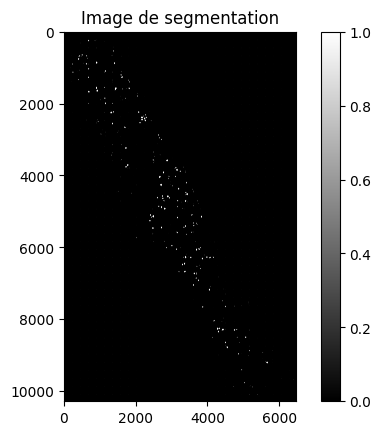

In [54]:
import matplotlib.pyplot as plt

plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()